In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataevaluator import DataEvaluator
from helper import evaluate_model, train_model
from scikeras.wrappers import KerasClassifier

from models.knn import KNN
from models.mlp import MLP
from models.logistic import LogReg
from models.cnn import CNN

In [3]:
data = DataEvaluator('dataset')
X_train, y_train, X_val, y_val, X_test, y_test = data.get_data()
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)
clothing_types = data.clothing_types

(51000, 784) (51000,) (9000, 784) (9000,) (10000, 784) (10000,)


In [4]:
# CNN data preprocessing

X_train_cnn = X_train.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_val_cnn   = X_val.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_test_cnn  = X_test.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

print(X_train_cnn.shape)
print(X_val_cnn.shape)
print(X_test_cnn.shape)

(51000, 28, 28, 1)
(9000, 28, 28, 1)
(10000, 28, 28, 1)


## Data Exploration

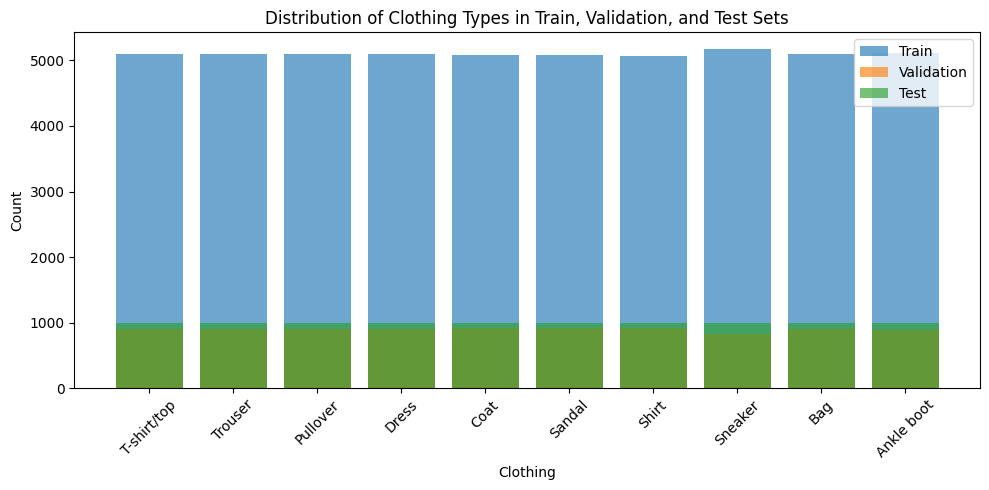

In [5]:
data.plot_clothing_distribution()
print()

# Model Initialization Logic Here

In [6]:
l = LogReg()
k = KNN()
f = MLP()
c = CNN()

# Training Models

In [7]:
ltime, _ = train_model(l, "Logistic Regression", X_train, y_train)
print(f"Training time for Logistic Regression: {ltime:.2f} seconds")

KeyboardInterrupt: 

In [ ]:
kfit_time, _ = train_model(k, "kNN", X_train, y_train)
print(f"Training time for kNN: {kfit_time:.2f} seconds")

Training time for kNN: 0.01 seconds


Training time for MLP: 235.37 seconds


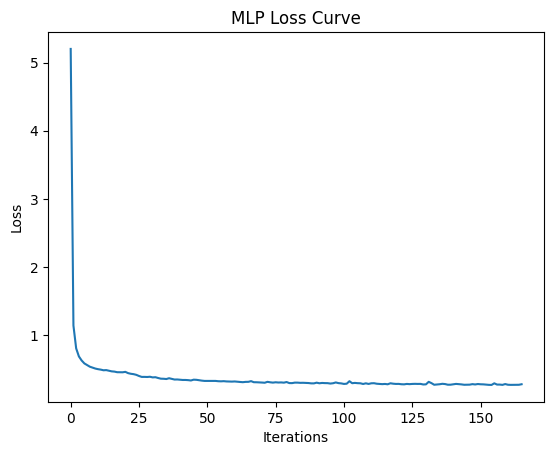

In [ ]:
ftime, _ = train_model(f, "MLP", X_train, y_train)
print(f"Training time for MLP: {ftime:.2f} seconds")

plt.plot(f.classifier.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Loss Curve')
plt.savefig('figures/MLP_loss_curve.png')
plt.show()

Epoch 1/30


c:\Users\Oboes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7618 - loss: 0.6604 - learning_rate: 0.0010
Epoch 2/30
  8/399 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8241 - loss: 0.5372

c:\Users\Oboes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\Oboes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8459 - loss: 0.4276 - learning_rate: 0.0010
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8682 - loss: 0.3665 - learning_rate: 0.0010
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8782 - loss: 0.3320 - learning_rate: 0.0010
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8889 - loss: 0.3048 - learning_rate: 0.0010
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8963 - loss: 0.2845 - learning_rate: 0.0010
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9024 - loss: 0.2661 - learning_rate: 0.0010
Epoch 8/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9072 - loss: 0.2531 - learning_rate: 0.0010
Epoch 9/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9129 - loss: 0.2369 - learning_rate: 0.0010
Epoch 10/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9158 - loss: 0.2281 - learning_rate: 0.0010
Epoch 11/30

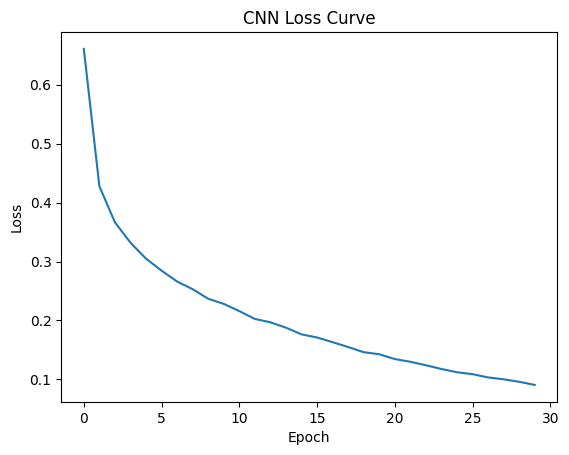

In [7]:
ctime, history = train_model(c, "CNN", X_train_cnn, y_train)
print(f"Training time for CNN: {ctime:.2f} seconds")

loss = c.history_["loss"]

plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Curve")
plt.savefig('figures/CNN_loss_curve.png')
plt.show()

Logistic Regression Accuracy: 0.8352222222222222  Precision: 0.8340474861761206  Recall: 0.8352222222222222  F1 Score: 0.8341134022212633


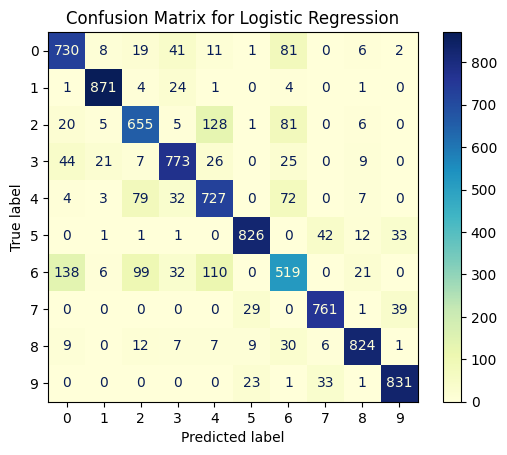

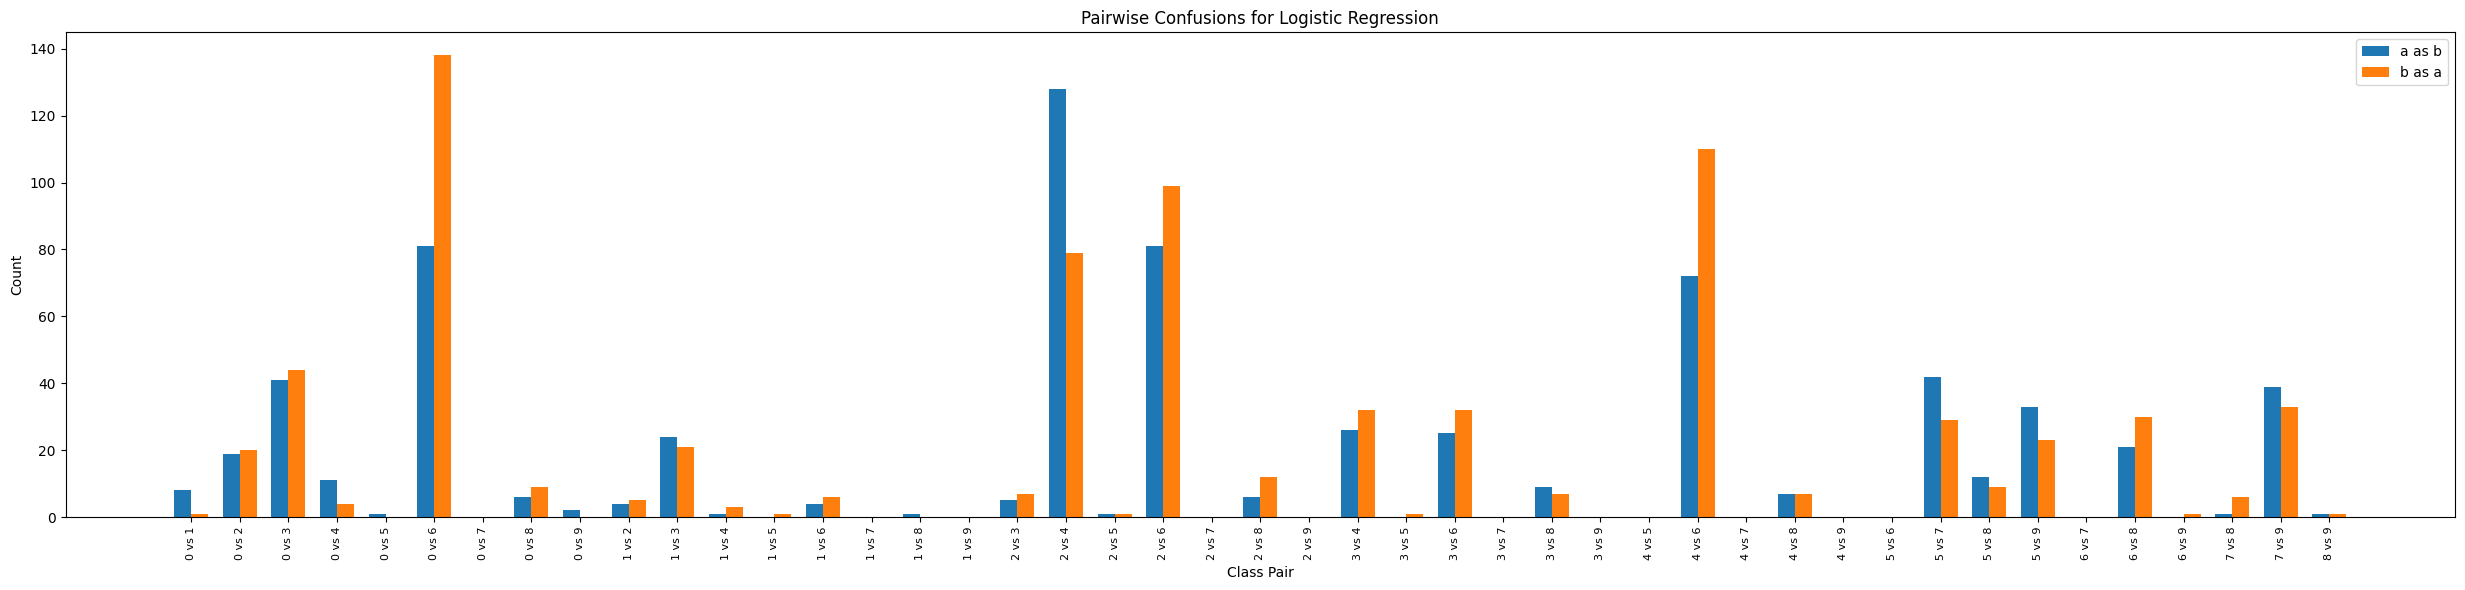

Logistic Regression class 0 AUC: 0.9802065112602998
Logistic Regression class 1 AUC: 0.9976974468319542
Logistic Regression class 2 AUC: 0.9698207490298676
Logistic Regression class 3 AUC: 0.9887269612577165
Logistic Regression class 4 AUC: 0.9731504977604531
Logistic Regression class 5 AUC: 0.9957397382073383
Logistic Regression class 6 AUC: 0.932103957827797
Logistic Regression class 7 AUC: 0.996033091976228
Logistic Regression class 8 AUC: 0.9894539634656138
Logistic Regression class 9 AUC: 0.996366222931294


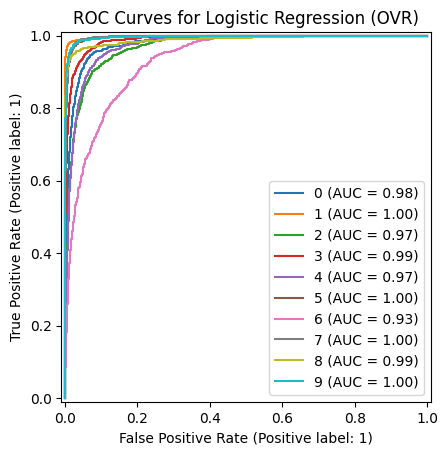

Logistic Regression pair 0 vs 7 AUC: 0.9999772169880858
Logistic Regression pair 1 vs 7 AUC: 0.99998404212878
Logistic Regression pair 1 vs 9 AUC: 0.9999192981671993


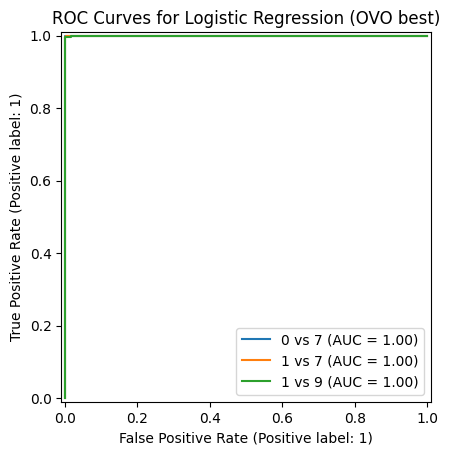

Logistic Regression pair 0 vs 6 AUC: 0.8304602711721732
Logistic Regression pair 2 vs 4 AUC: 0.8996497398273203
Logistic Regression pair 4 vs 6 AUC: 0.8447654147654148
Logistic Regression pair 2 vs 6 AUC: 0.824020157782644
Logistic Regression pair 0 vs 3 AUC: 0.9703365925306818


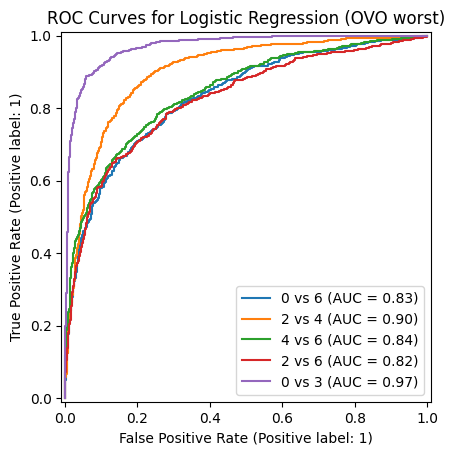

Validation time for Logistic Regression: 1.25 seconds


In [ ]:
le, levals, letime = evaluate_model(l, "Logistic Regression", X_val, y_val, stage="validation", color="YlGnBu")
print(f"Validation time for Logistic Regression: {letime:.2f} seconds")

kNN Accuracy: 0.8485555555555555  Precision: 0.8518505535144103  Recall: 0.8485555555555555  F1 Score: 0.8476630797526208


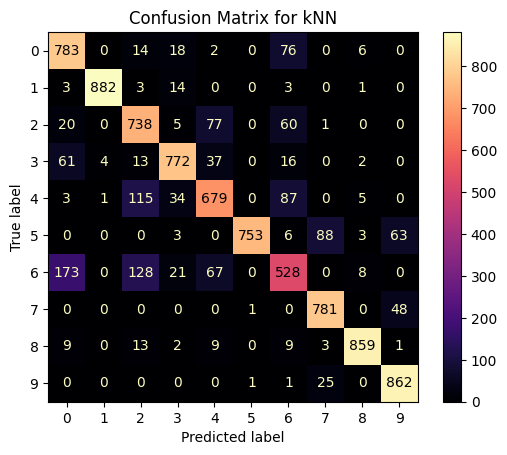

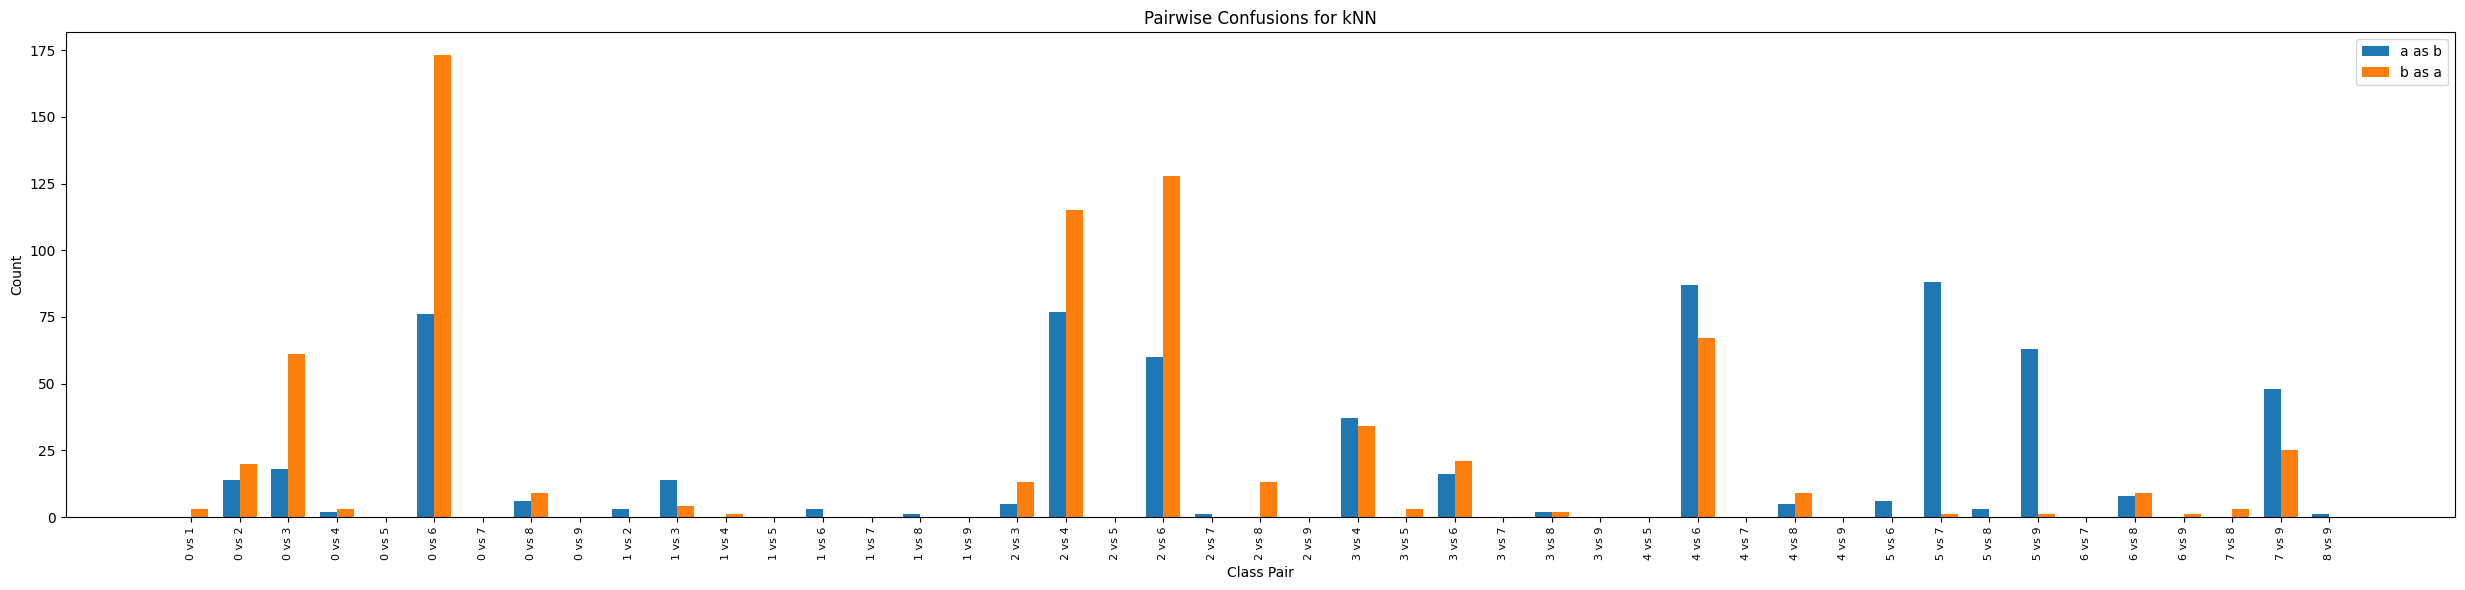

kNN class 0 AUC: 0.9604295683568913
kNN class 1 AUC: 0.9899958599044015
kNN class 2 AUC: 0.9398821383382856
kNN class 3 AUC: 0.9637601138415024
kNN class 4 AUC: 0.9297591441907935
kNN class 5 AUC: 0.960348653548224
kNN class 6 AUC: 0.865319655258974
kNN class 7 AUC: 0.9873783014555162
kNN class 8 AUC: 0.9812588085544928
kNN class 9 AUC: 0.9907071858281308


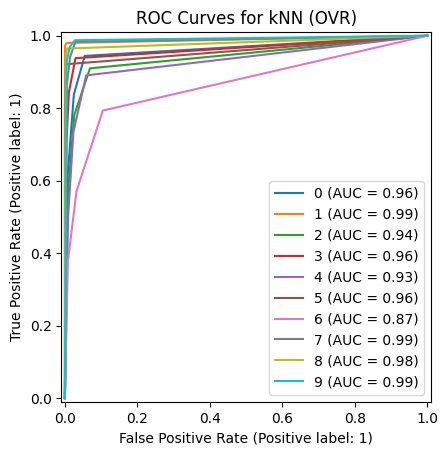

kNN pair 0 vs 5 AUC: 0.9606986899563319
kNN pair 0 vs 7 AUC: 0.991566265060241
kNN pair 0 vs 9 AUC: 0.9938132733408325


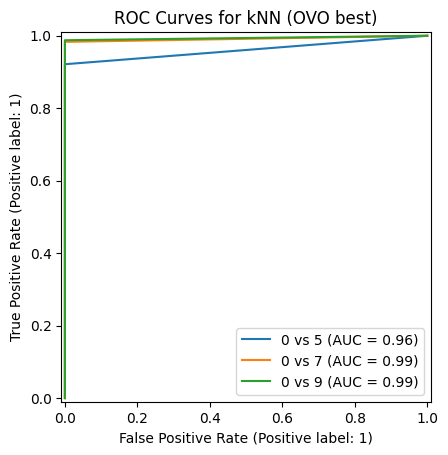

kNN pair 0 vs 6 AUC: 0.8114523644890719
kNN pair 2 vs 4 AUC: 0.8864555256064691
kNN pair 2 vs 6 AUC: 0.8267054623991361
kNN pair 4 vs 6 AUC: 0.8169322569322569
kNN pair 5 vs 7 AUC: 0.9653732835271216


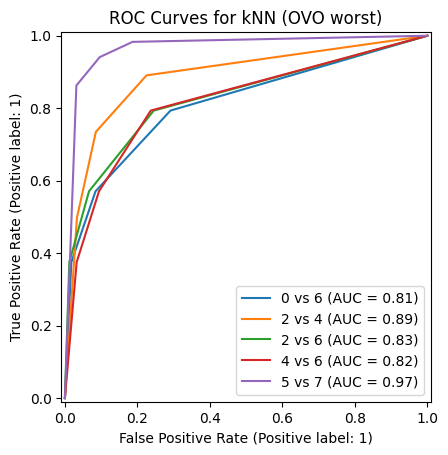

Validation time for kNN: 21.85 seconds


In [ ]:
ke, kevals, k_eval_time = evaluate_model(k, "kNN", X_val, y_val, stage="validation", color="magma")
print(f"Validation time for kNN: {k_eval_time:.2f} seconds")

MLP Accuracy: 0.8466666666666667  Precision: 0.8486317903415196  Recall: 0.8466666666666667  F1 Score: 0.845625088986641


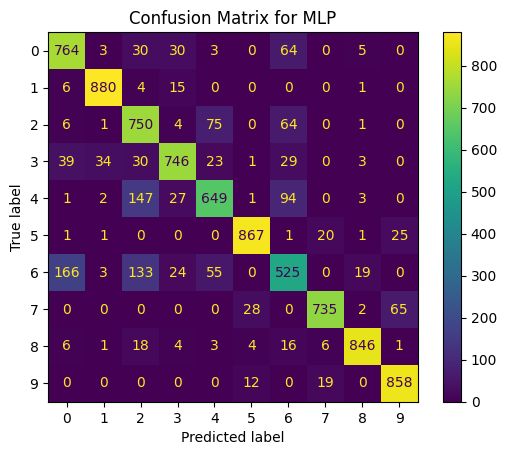

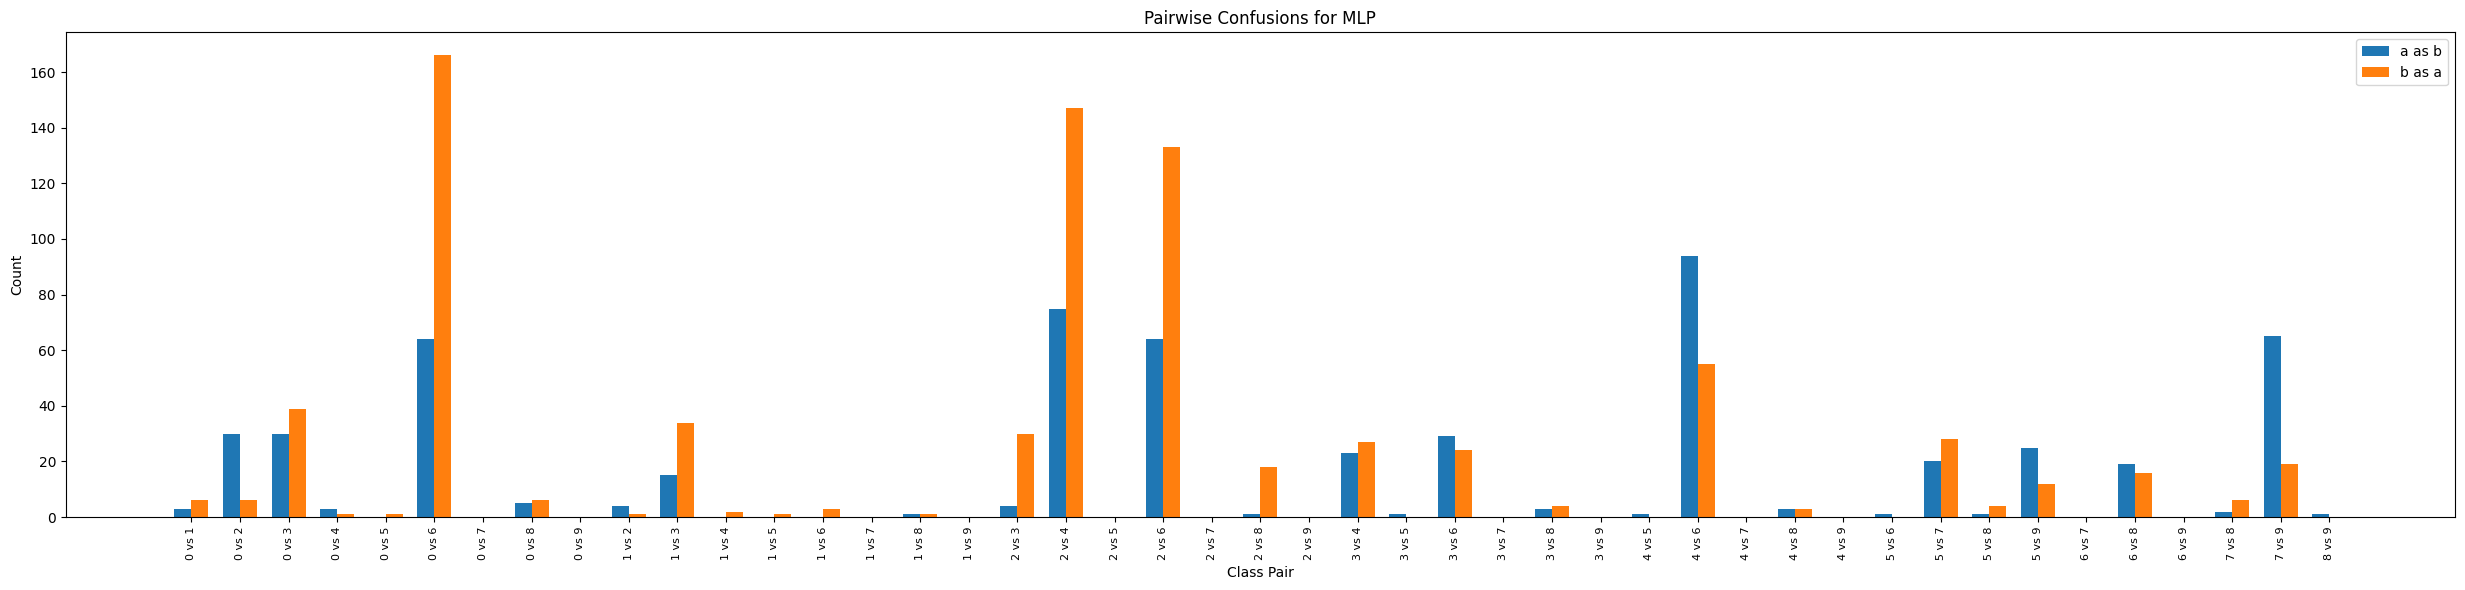

MLP class 0 AUC: 0.9837786268713443
MLP class 1 AUC: 0.9969982943242508
MLP class 2 AUC: 0.9750353526058424
MLP class 3 AUC: 0.9873773798026882
MLP class 4 AUC: 0.9778559314220533
MLP class 5 AUC: 0.9971256366017083
MLP class 6 AUC: 0.9456187432014059
MLP class 7 AUC: 0.9958630605653951
MLP class 8 AUC: 0.989168540706186
MLP class 9 AUC: 0.9964487394321672


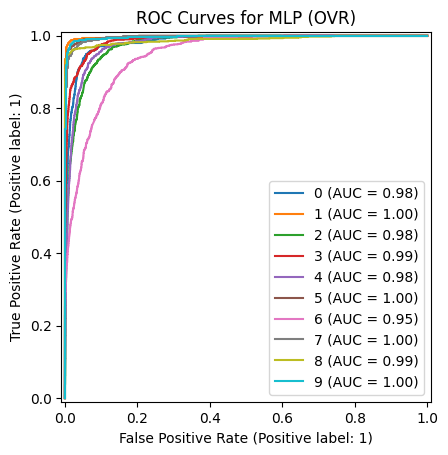

MLP pair 0 vs 7 AUC: 0.9987898200142058
MLP pair 0 vs 9 AUC: 0.9989189337984588
MLP pair 1 vs 7 AUC: 0.9999946807095933


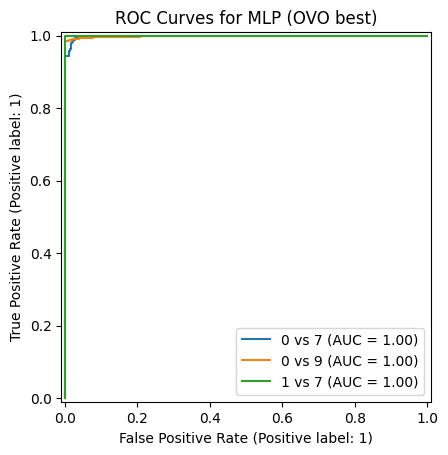

MLP pair 0 vs 6 AUC: 0.8757237771698284
MLP pair 2 vs 4 AUC: 0.9094116205658938
MLP pair 2 vs 6 AUC: 0.8505276419593844
MLP pair 4 vs 6 AUC: 0.8757189657189658
MLP pair 7 vs 9 AUC: 0.9816539498827705


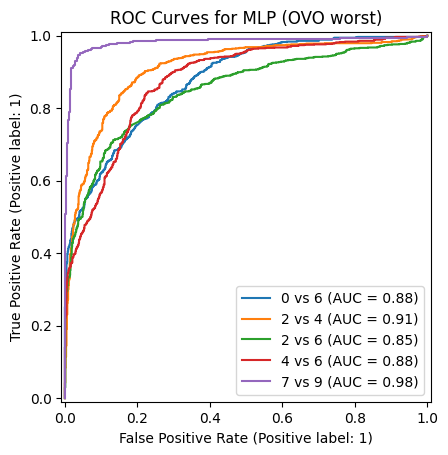

Validation time for MLP: 2.04 seconds


In [ ]:
fe, fevals, fetime = evaluate_model(f, "MLP", X_val, y_val, stage="validation", color="viridis")
print(f"Validation time for MLP: {fetime:.2f} seconds")

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
CNN Accuracy: 0.9176666666666666  Precision: 0.9179231845460355  Recall: 0.9176666666666666  F1 Score: 0.9170953664308571


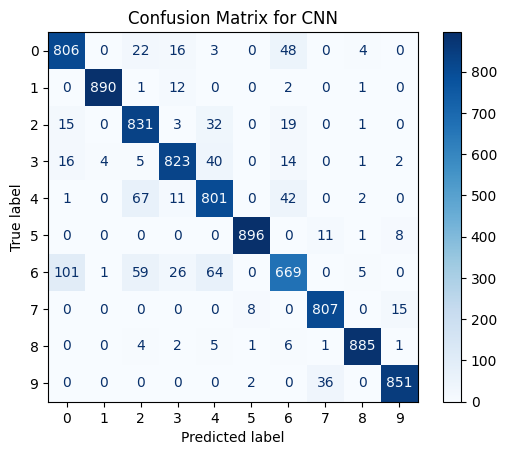

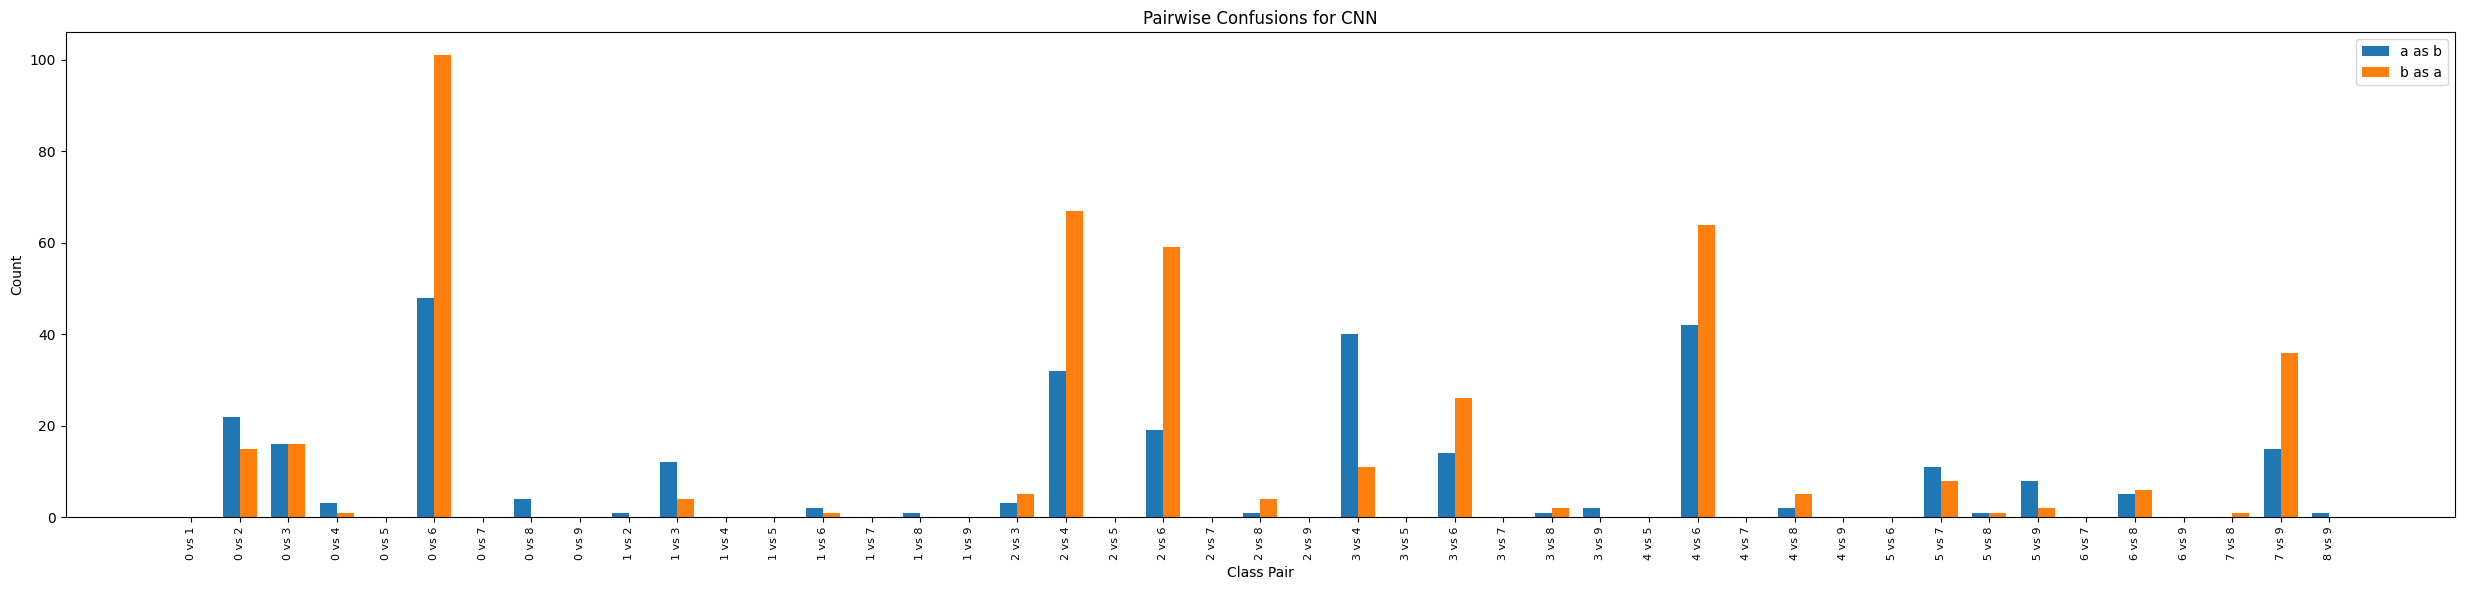

CNN class 0 AUC: 0.9945172178993269
CNN class 1 AUC: 0.9996323551471097
CNN class 2 AUC: 0.9935408092886051
CNN class 3 AUC: 0.9965914434597443
CNN class 4 AUC: 0.9912500616438209
CNN class 5 AUC: 0.9998303835923675
CNN class 6 AUC: 0.9795970881097816
CNN class 7 AUC: 0.9990946159177714
CNN class 8 AUC: 0.9996921911417934
CNN class 9 AUC: 0.9993813342682429


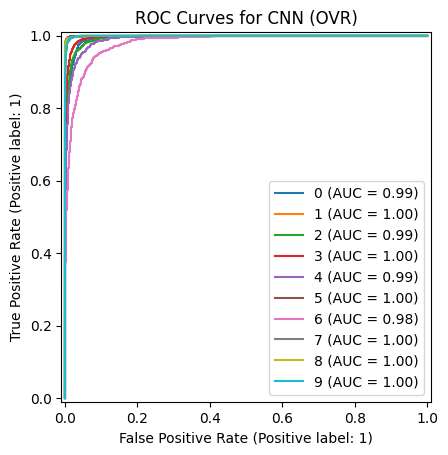

CNN pair 0 vs 1 AUC: 0.9996991997485556
CNN pair 0 vs 5 AUC: 0.9999757129464568
CNN pair 0 vs 7 AUC: 0.9998204162590293


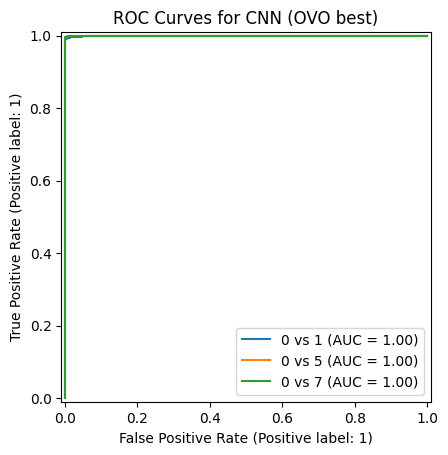

CNN pair 0 vs 6 AUC: 0.9430261852508793
CNN pair 4 vs 6 AUC: 0.9477571077571078
CNN pair 2 vs 4 AUC: 0.9808221744958703
CNN pair 2 vs 6 AUC: 0.9605195428502865
CNN pair 7 vs 9 AUC: 0.99603520945424


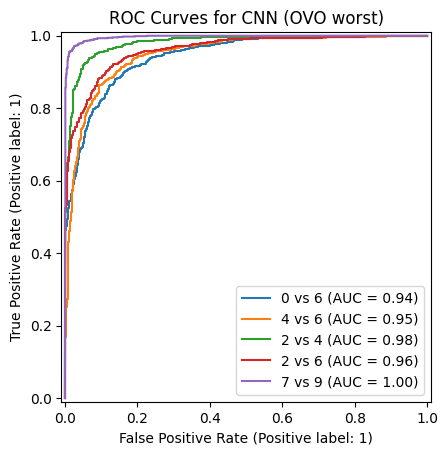

Validation time for CNN: 2.42 seconds


In [8]:
ce, cevals, ctime = evaluate_model(c, "CNN", X_val_cnn, y_val, stage="validation", color="Blues")
print(f"Validation time for CNN: {ctime:.2f} seconds")

# Final Testing and Evaluations

Logistic Regression Accuracy: 0.8291  Precision: 0.827607618530111  Recall: 0.8291  F1 Score: 0.8279826523929662


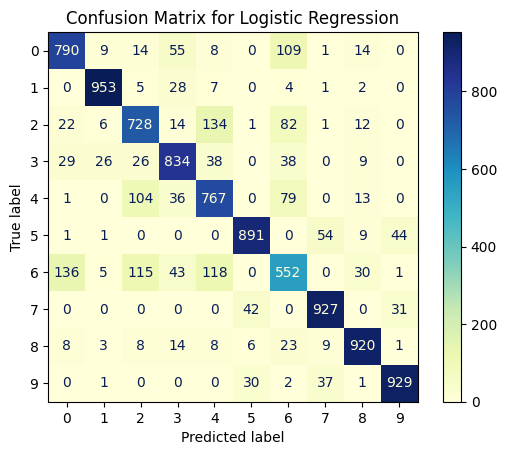

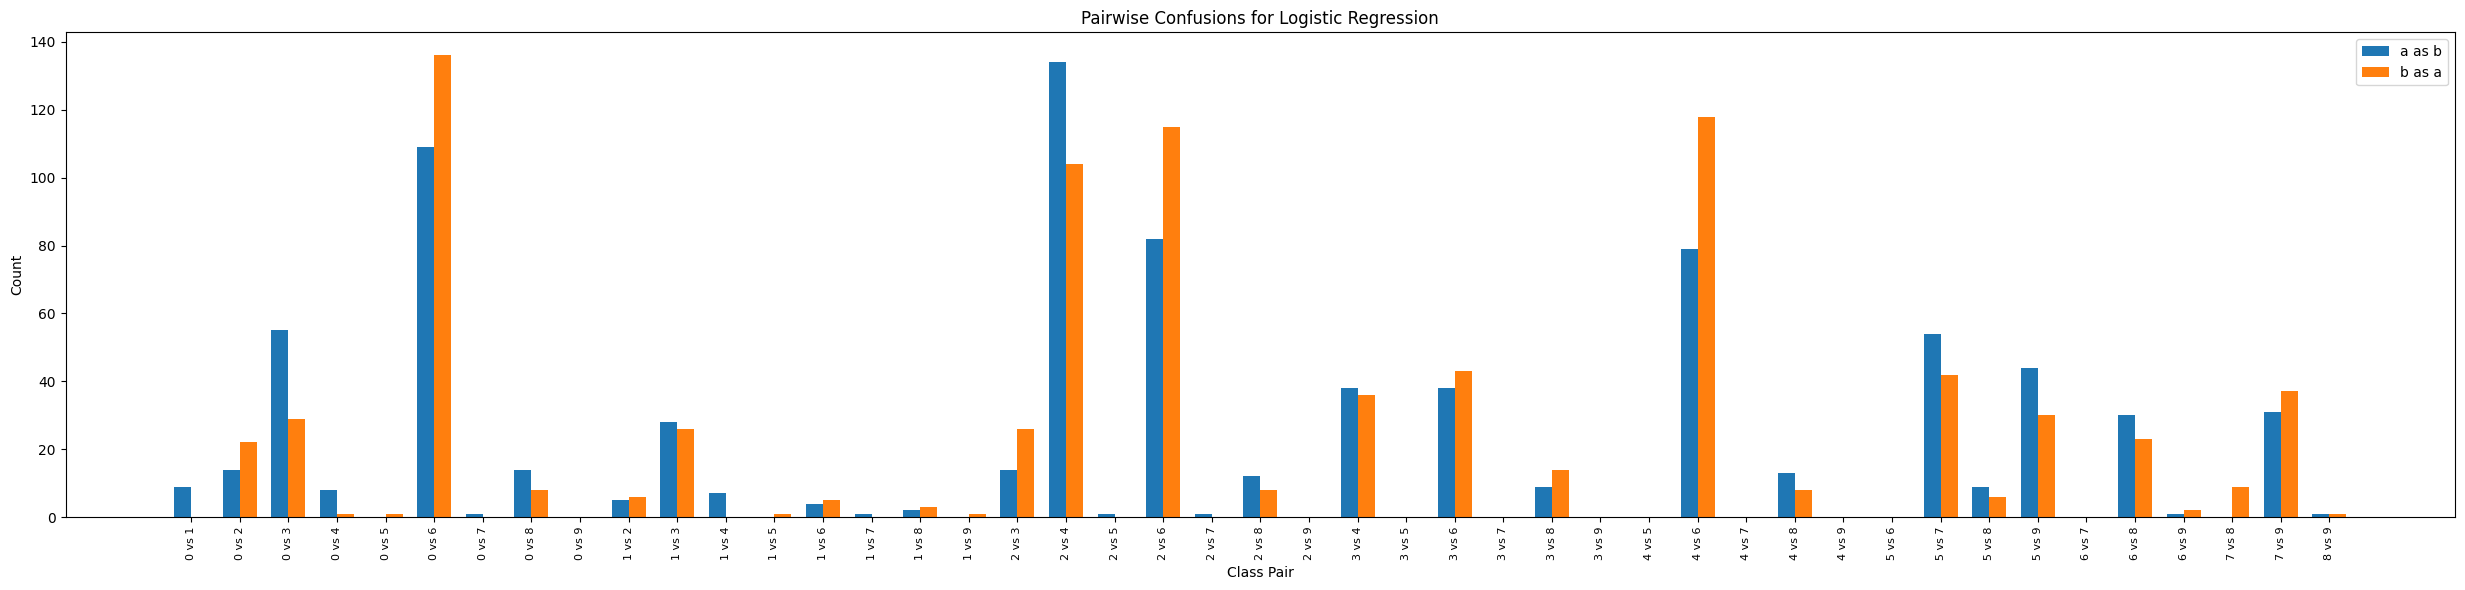

Logistic Regression class 0 AUC: 0.9788772222222223
Logistic Regression class 1 AUC: 0.9977276666666667
Logistic Regression class 2 AUC: 0.9677875555555556
Logistic Regression class 3 AUC: 0.9850218888888889
Logistic Regression class 4 AUC: 0.9708538888888889
Logistic Regression class 5 AUC: 0.9950825555555556
Logistic Regression class 6 AUC: 0.9268768888888889
Logistic Regression class 7 AUC: 0.9962942222222221
Logistic Regression class 8 AUC: 0.9918193333333334
Logistic Regression class 9 AUC: 0.9969540000000001


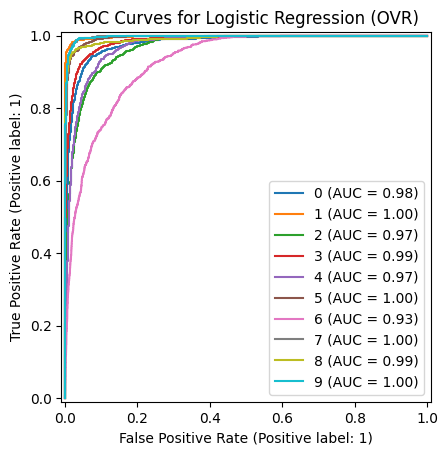

Logistic Regression pair 0 vs 9 AUC: 0.999902
Logistic Regression pair 2 vs 9 AUC: 0.999984
Logistic Regression pair 3 vs 5 AUC: 0.999927


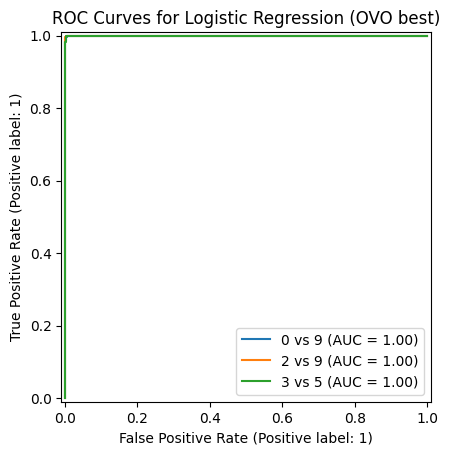

Logistic Regression pair 0 vs 6 AUC: 0.812249
Logistic Regression pair 2 vs 4 AUC: 0.8964319999999999
Logistic Regression pair 4 vs 6 AUC: 0.829558
Logistic Regression pair 2 vs 6 AUC: 0.819463
Logistic Regression pair 5 vs 7 AUC: 0.9842879999999999


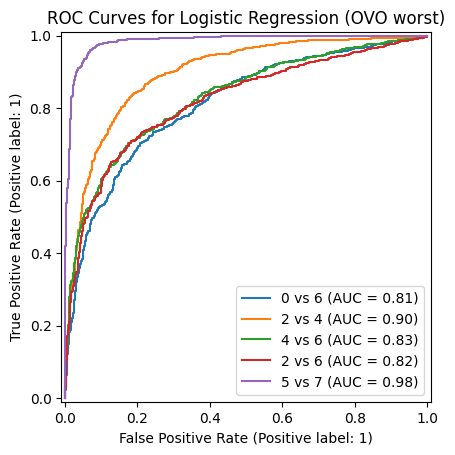

Test time for Logistic Regression: 1.35 seconds


In [ ]:
le_test, le_test_vals, le_test_time = evaluate_model(l, "Logistic Regression", X_test, y_test, stage="test", color="YlGnBu")
print(f"Test time for Logistic Regression: {le_test_time:.2f} seconds")

kNN Accuracy: 0.8483  Precision: 0.8520615941176211  Recall: 0.8483  F1 Score: 0.8481758846976906


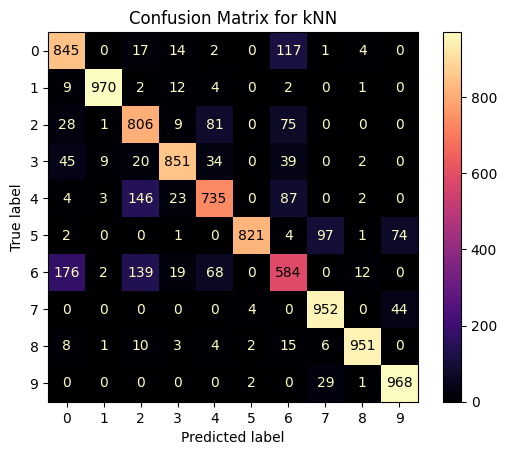

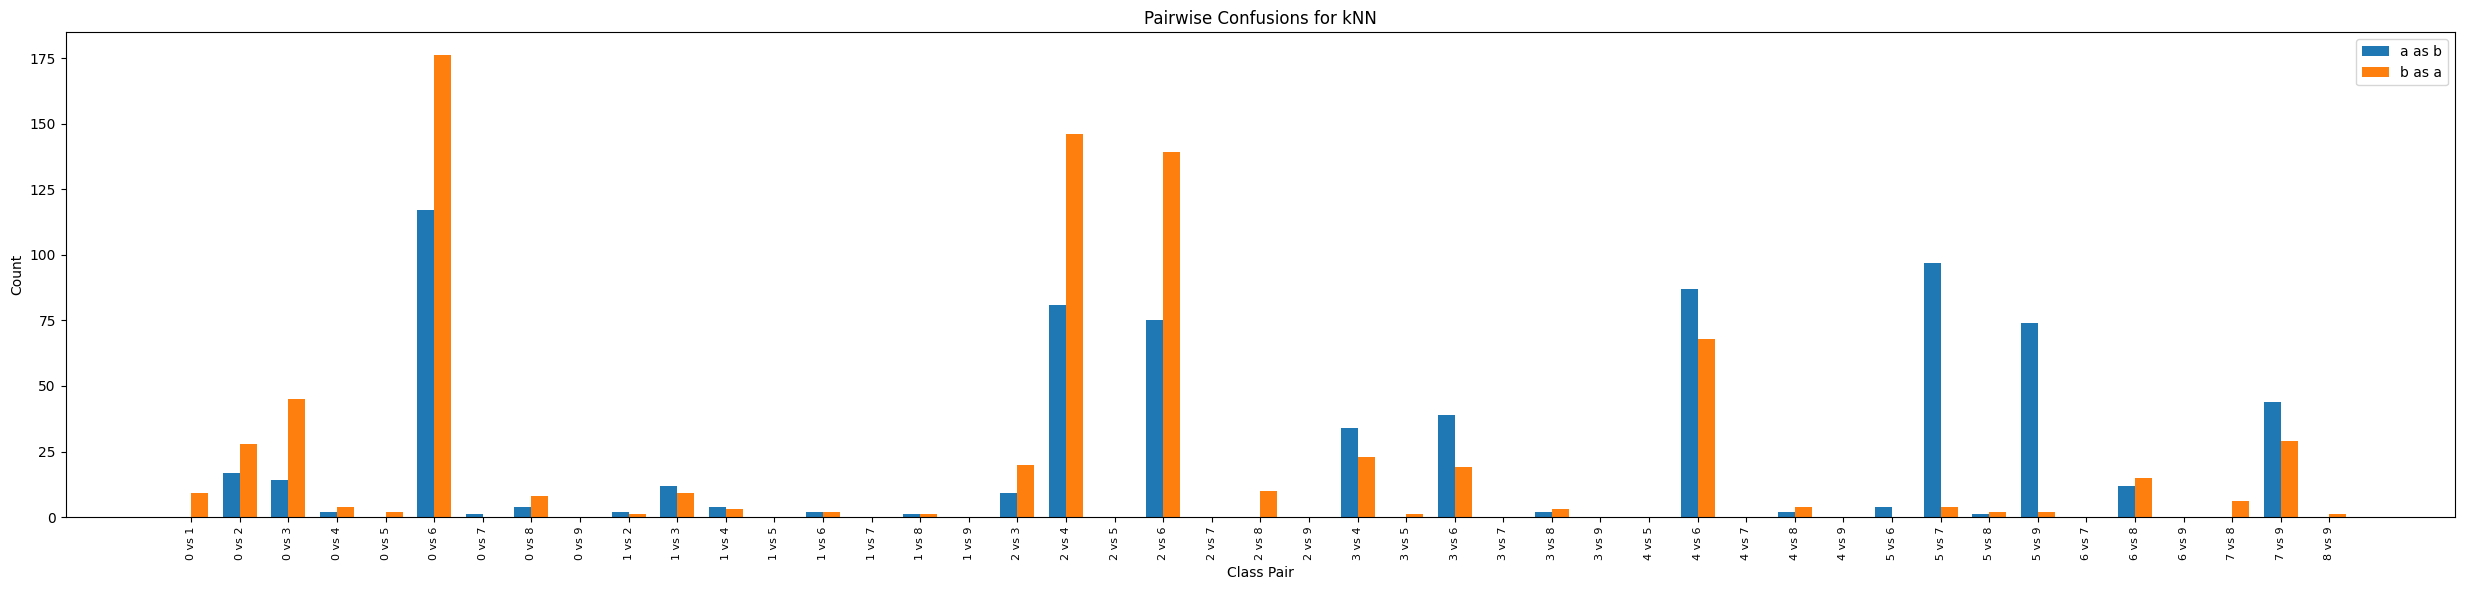

kNN class 0 AUC: 0.9543931666666666
kNN class 1 AUC: 0.9907961666666666
kNN class 2 AUC: 0.9387239999999999
kNN class 3 AUC: 0.9590384444444445
kNN class 4 AUC: 0.9351102222222222
kNN class 5 AUC: 0.9556955555555556
kNN class 6 AUC: 0.8698565
kNN class 7 AUC: 0.9894025000000001
kNN class 8 AUC: 0.9848589444444444
kNN class 9 AUC: 0.9904855555555555


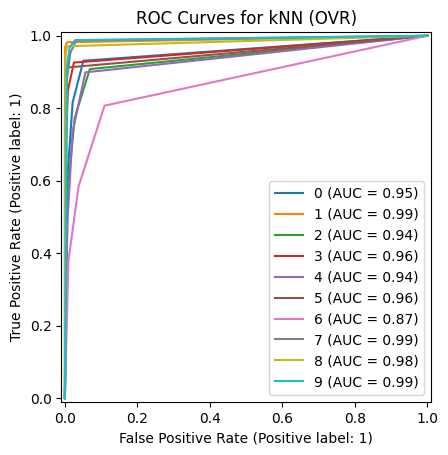

kNN pair 0 vs 9 AUC: 0.994
kNN pair 1 vs 5 AUC: 0.956
kNN pair 1 vs 7 AUC: 0.9935


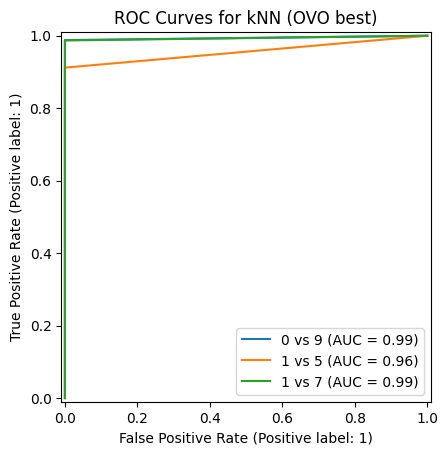

kNN pair 0 vs 6 AUC: 0.8052515
kNN pair 2 vs 4 AUC: 0.8955385
kNN pair 2 vs 6 AUC: 0.8331485
kNN pair 4 vs 6 AUC: 0.8235785
kNN pair 5 vs 7 AUC: 0.9684685000000001


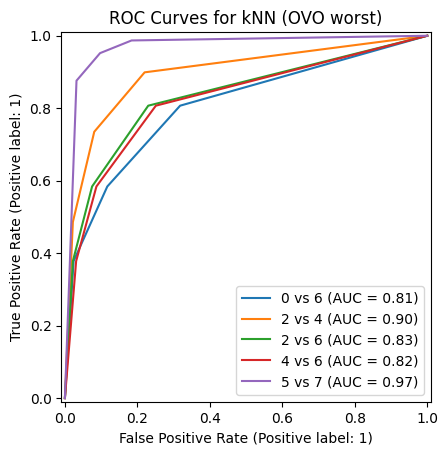

Test time for kNN: 28.02 seconds


In [ ]:
ke_test, ke_test_vals, ke_test_time = evaluate_model(k, "kNN", X_test, y_test, stage="test", color="magma")
print(f"Test time for kNN: {ke_test_time:.2f} seconds")

MLP Accuracy: 0.8454  Precision: 0.8474505644800372  Recall: 0.8454  F1 Score: 0.8446780294416796


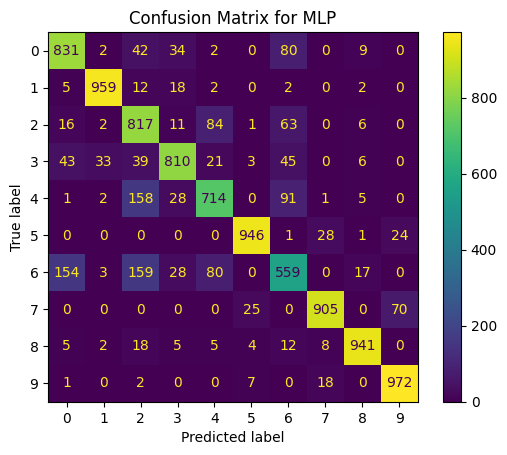

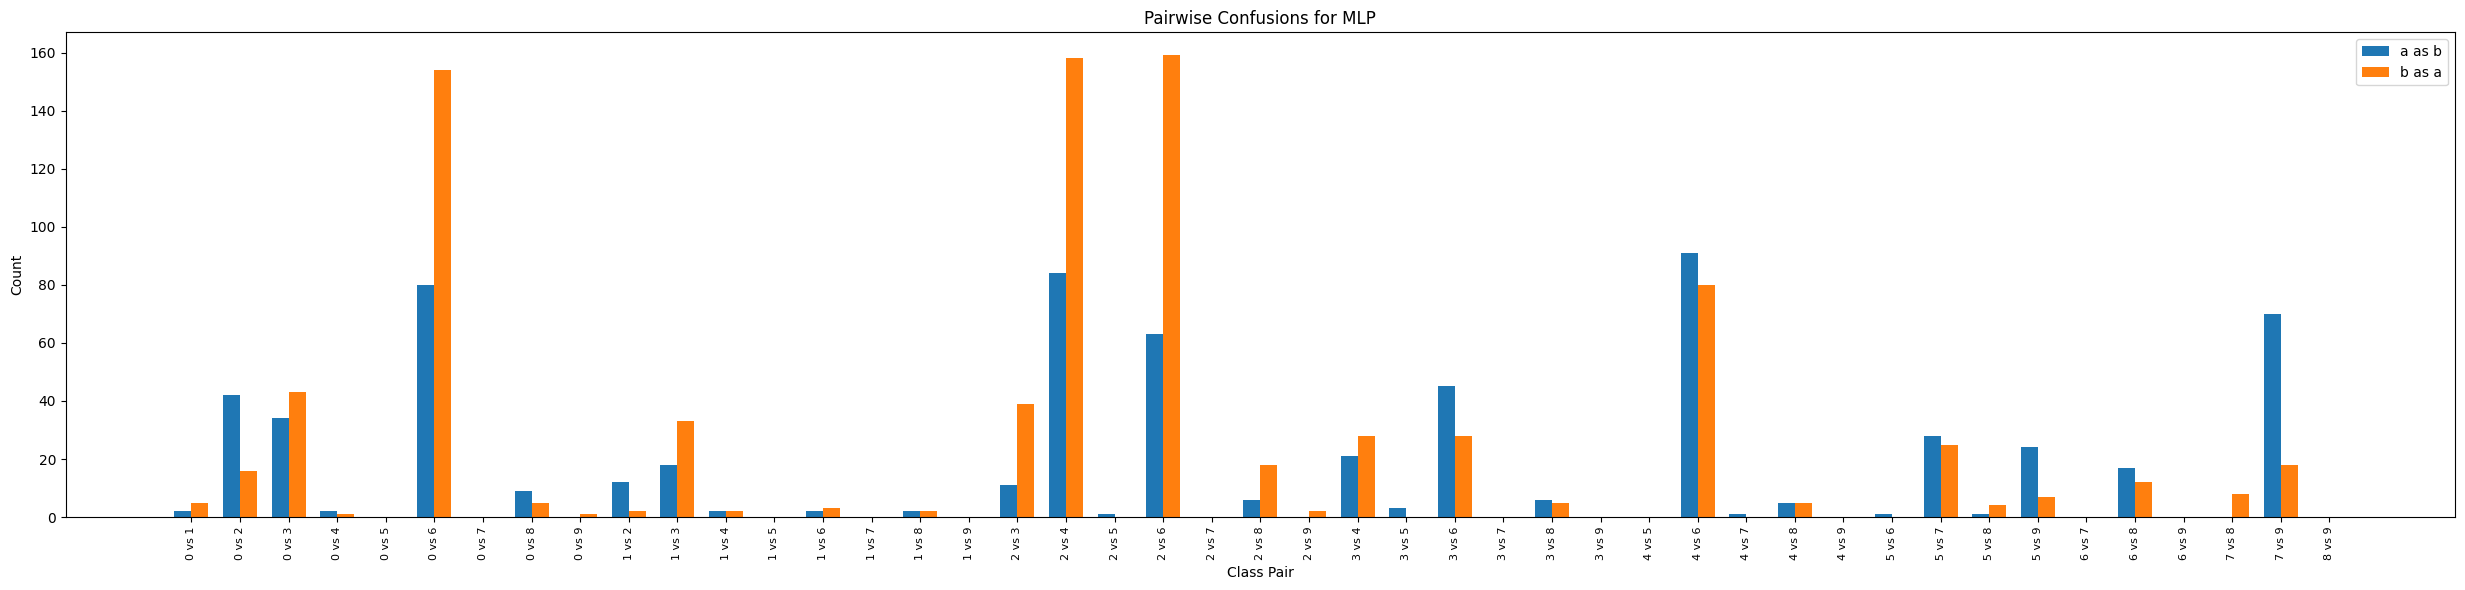

MLP class 0 AUC: 0.9819335555555555
MLP class 1 AUC: 0.9962157777777778
MLP class 2 AUC: 0.9692086666666667
MLP class 3 AUC: 0.985607888888889
MLP class 4 AUC: 0.9768424444444445
MLP class 5 AUC: 0.9966231666666667
MLP class 6 AUC: 0.9411106666666667
MLP class 7 AUC: 0.9957904444444444
MLP class 8 AUC: 0.9902048888888889
MLP class 9 AUC: 0.997427


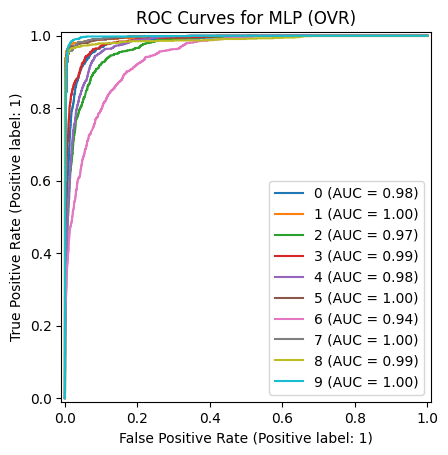

MLP pair 0 vs 5 AUC: 0.997767
MLP pair 0 vs 7 AUC: 0.998864
MLP pair 1 vs 5 AUC: 0.999911


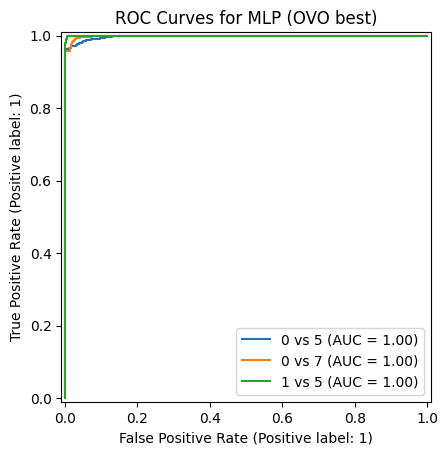

MLP pair 2 vs 4 AUC: 0.9016144999999999
MLP pair 0 vs 6 AUC: 0.853683
MLP pair 2 vs 6 AUC: 0.844499
MLP pair 4 vs 6 AUC: 0.872234
MLP pair 7 vs 9 AUC: 0.988808


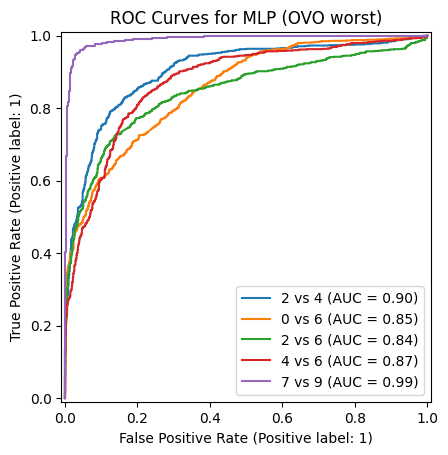

Test time for MLP: 1.77 seconds


In [ ]:
fe_test, fe_test_vals, fe_test_time = evaluate_model(f, "MLP", X_test, y_test, stage="test", color="viridis")
print(f"Test time for MLP: {fe_test_time:.2f} seconds")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN Accuracy: 0.9117  Precision: 0.9120131932451108  Recall: 0.9117  F1 Score: 0.9116363967697922


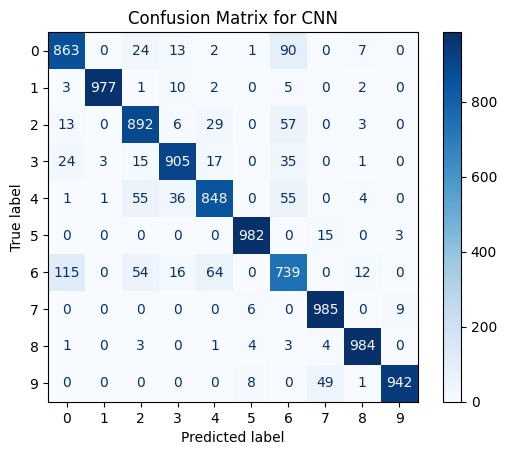

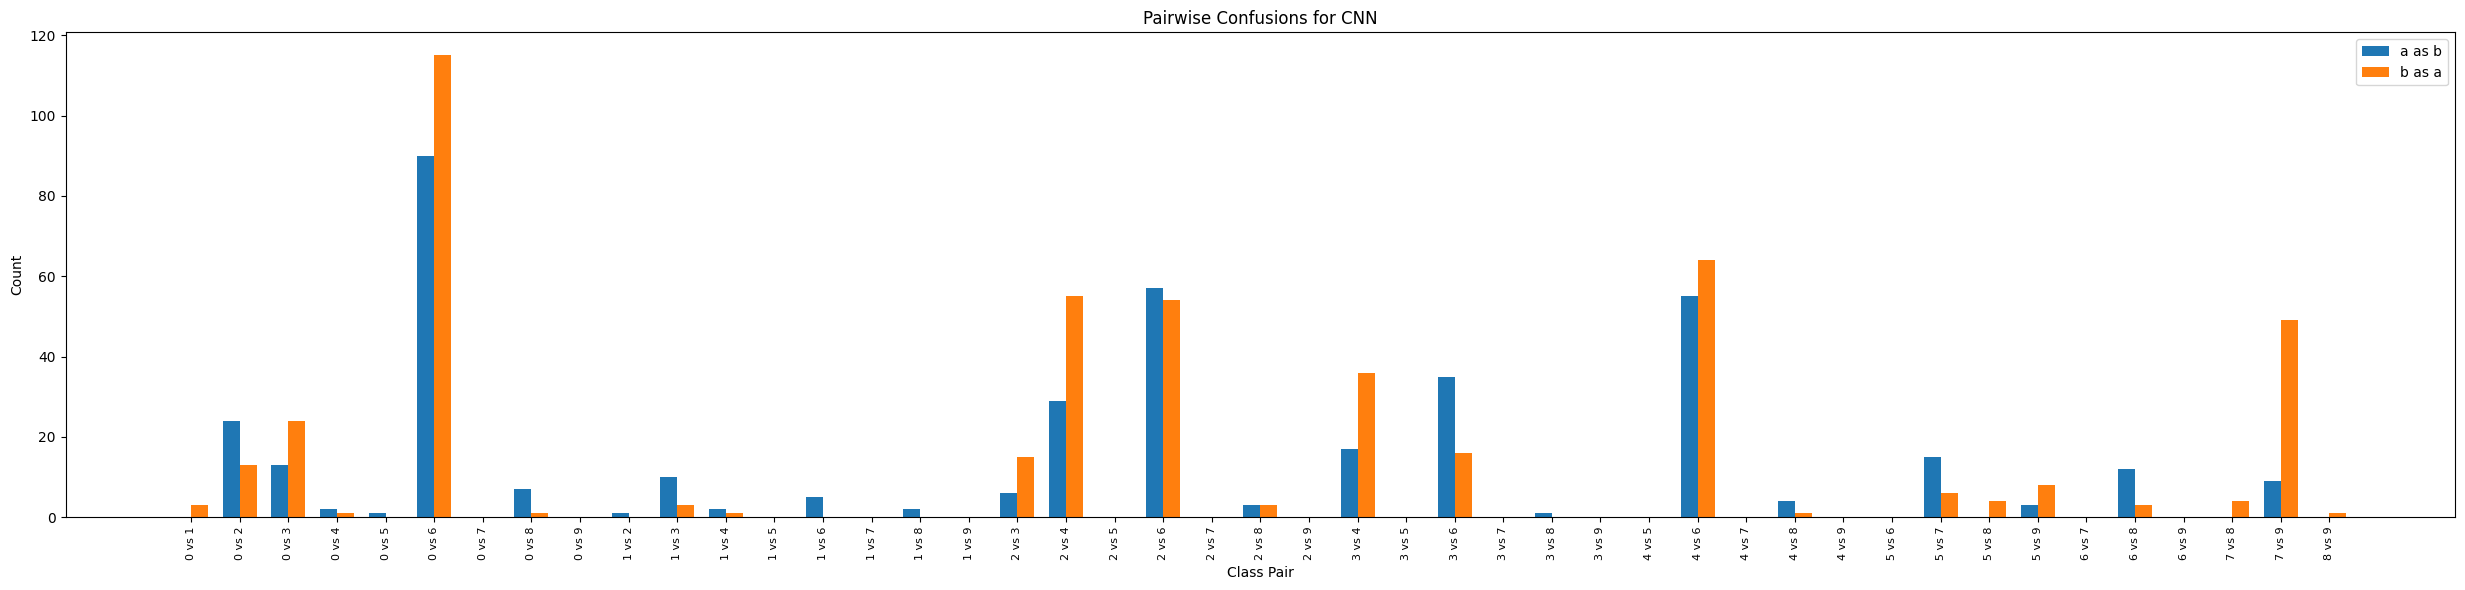

CNN class 0 AUC: 0.992391
CNN class 1 AUC: 0.9995651111111111
CNN class 2 AUC: 0.9917267222222222
CNN class 3 AUC: 0.9965843333333333
CNN class 4 AUC: 0.9920405555555555
CNN class 5 AUC: 0.9998188888888889
CNN class 6 AUC: 0.9753024444444444
CNN class 7 AUC: 0.9992903333333333
CNN class 8 AUC: 0.9995065555555556
CNN class 9 AUC: 0.9992805


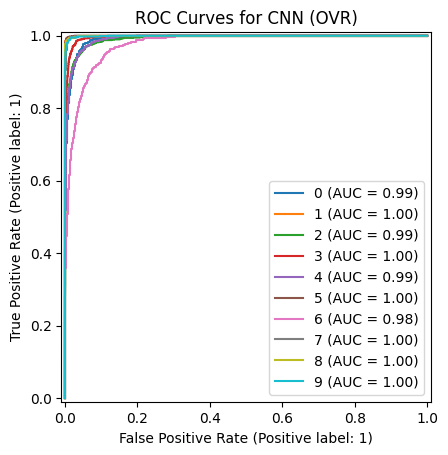

CNN pair 0 vs 7 AUC: 0.9999439999999999
CNN pair 0 vs 9 AUC: 0.9998889999999999
CNN pair 1 vs 5 AUC: 0.999992


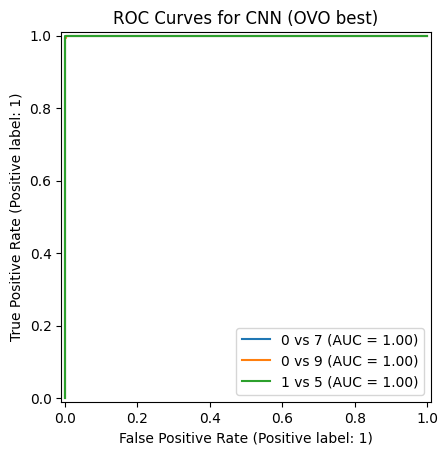

CNN pair 0 vs 6 AUC: 0.923128
CNN pair 4 vs 6 AUC: 0.942688
CNN pair 2 vs 6 AUC: 0.9475689999999999
CNN pair 2 vs 4 AUC: 0.9814890000000001
CNN pair 7 vs 9 AUC: 0.9956655000000001


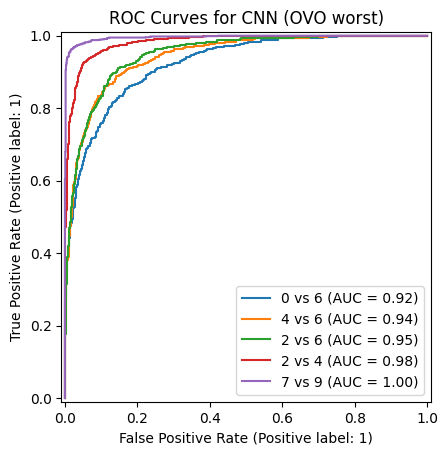

Test time for CNN: 2.51 seconds


In [ ]:
ce_test, ce_test_vals, ce_test_time = evaluate_model(c, "CNN", X_test_cnn, y_test, stage="test", color="Blues")
print(f"Test time for CNN: {ce_test_time:.2f} seconds")

# Comparing All Models

In [ ]:
models = ["Logistic Regression", "kNN", "MLP", "CNN"]
catcounts = {"Logistic Regression": np.diag(levals.cm) , "kNN": np.diag(kevals.cm) , "MLP": np.diag(fevals.cm), "CNN": np.diag(cevals.cm)}
cataccs = {model: counts/(len(y_test)/len(clothing_types)) for model, counts in catcounts.items()}

# Graph the numeric accuracies
x = np.arange(len(clothing_types))
width = 0.275
[plt.bar(x - width + i*width, catcounts[model], width, label=model) for i, model in enumerate(models)]
plt.xlabel('Clothing Category')
plt.ylabel('Number of Correct Predictions')
plt.title('Accuracy of Models by Clothing Category')
plt.xticks(x, [clothing_types[i] for i in clothing_types.keys()], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('figures/model_category_accuracies.png')
plt.show()

NameError: name 'levals' is not defined

In [ ]:
[print(f"{model} Category Accuracy: {cataccs[model]}") for model in models]
totaccs = {model: np.round(np.mean(cataccs[model]), 4) for model in models}
print("Sorted by Overall Accuracy:", sorted([{"Logistic Regression": totaccs["Logistic Regression"]}, {"kNN": totaccs["kNN"]}, {"MLP": totaccs["MLP"]}], key=lambda x: list(x.values())[0], reverse=True))

Logistic Regression Category Accuracy: [0.73  0.871 0.655 0.773 0.727 0.826 0.519 0.761 0.824 0.831]
kNN Category Accuracy: [0.783 0.882 0.738 0.772 0.679 0.753 0.528 0.781 0.859 0.862]
MLP Category Accuracy: [0.764 0.88  0.75  0.746 0.649 0.867 0.525 0.735 0.846 0.858]
CNN Category Accuracy: [0.797 0.878 0.694 0.776 0.741 0.884 0.447 0.776 0.869 0.857]
Sorted by Overall Accuracy: [{'kNN': np.float64(0.7637)}, {'MLP': np.float64(0.762)}, {'Logistic Regression': np.float64(0.7517)}]


In [ ]:
performance_by_category = pd.DataFrame({model: cataccs[model] for model in models}, index=[clothing_types[i] for i in clothing_types.keys()])
print("Performance by Category:", performance_by_category, sep="\n")
print("\nSorted by Category Accuracy:")
for category in performance_by_category.index:
    sorted_models = performance_by_category.loc[category].sort_values(ascending=False)
    print(f"Category {category}: {sorted_models.to_dict()}")

Performance by Category:
             Logistic Regression    kNN    MLP    CNN
T-shirt/top                0.730  0.783  0.764  0.797
Trouser                    0.871  0.882  0.880  0.878
Pullover                   0.655  0.738  0.750  0.694
Dress                      0.773  0.772  0.746  0.776
Coat                       0.727  0.679  0.649  0.741
Sandal                     0.826  0.753  0.867  0.884
Shirt                      0.519  0.528  0.525  0.447
Sneaker                    0.761  0.781  0.735  0.776
Bag                        0.824  0.859  0.846  0.869
Ankle boot                 0.831  0.862  0.858  0.857

Sorted by Category Accuracy:
Category T-shirt/top: {'CNN': 0.797, 'kNN': 0.783, 'MLP': 0.764, 'Logistic Regression': 0.73}
Category Trouser: {'kNN': 0.882, 'MLP': 0.88, 'CNN': 0.878, 'Logistic Regression': 0.871}
Category Pullover: {'MLP': 0.75, 'kNN': 0.738, 'CNN': 0.694, 'Logistic Regression': 0.655}
Category Dress: {'CNN': 0.776, 'Logistic Regression': 0.773, 'kNN': 0.772, '

In [ ]:
best_model_by_category = performance_by_category.idxmax(axis=1)
print(f"Best model by category:", best_model_by_category, sep="\n")
print(f"Model best performace counts by category: \n{best_model_by_category.value_counts()}")
print(f"Model with most category wins: {best_model_by_category.value_counts().idxmax()}")

Best model by category:
T-shirt/top    CNN
Trouser        kNN
Pullover       MLP
Dress          CNN
Coat           CNN
Sandal         CNN
Shirt          kNN
Sneaker        kNN
Bag            CNN
Ankle boot     kNN
dtype: object
Model best performace counts by category: 
CNN    5
kNN    4
MLP    1
Name: count, dtype: int64
Model with most category wins: CNN
